diferentes taxas de acerto pros comentarios filhos
DISCORDAR pode significar muitas coisas, cuidado

features: rotulo anterior: entrar ou não

começar fazendo por simplicidade: rotulo anterior foi dado (gabarito), depois ir pra tabela
segundo problema: class hierarquica acumularia mais erros ainda. Talvez seria melhor fazer por 3 classes (concroda, discorda, neutro)

Abordagem:
Usar LLMs com embeddings e utilizar algoritmos de classificação tradicionais.

In [73]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import pygraphviz as pgv

### 1. Análise Exploratória do dataset bruto

In [54]:
# importação do dataset de treinamento
df = pd.read_csv('Dados/aborto-consolidated-parent-based_treinamento.tsv', sep='\t', decimal = ',', encoding = 'UTF-8')
print(df.columns)
df.tail()

Index(['target_id', 'target_message', 'id', 'parent_id', 'author',
       'parent_name', 'parent_message', 'message', 'parent_label',
       'target_parent_message', 'target_and_message', 'label'],
      dtype='object')


,target_id,target_message,id,parent_id,author,parent_name,parent_message,message,parent_label,target_parent_message,target_and_message,label
613,50,"Eu entendo que, como budista, acredito que a v...",12,11,Mr._William_Grant,Willie_Ross,">a vida é sagrada, seja ela no inicio, ou após...","Eu compreendo totalmente seus argumentos, poré...",Concorda,"Eu entendo que, como budista, acredito que a v...","Eu entendo que, como budista, acredito que a v...",Discorda
614,50,"Eu entendo que, como budista, acredito que a v...",13,12,Willie_Ross,Mr._William_Grant,"Eu compreendo totalmente seus argumentos, poré...","Eu dei a minha resposta sobre o ""aborto ser ac...",Discorda,"Eu entendo que, como budista, acredito que a v...","Eu entendo que, como budista, acredito que a v...",Concorda
615,51,"Se você perguntar que o aborto é aceitável, a ...",Alvo,Alvo,Alvo,Alvo,Alvo,"Se você perguntar que o aborto é aceitável, a ...",Alvo da conversa,"Se você perguntar que o aborto é aceitável, a ...","Se você perguntar que o aborto é aceitável, a ...",Alvo da conversa
616,51,"Se você perguntar que o aborto é aceitável, a ...",1,NaN,Jennifer_Brooks,Raiz,NaN,Não.,NaN,"Se você perguntar que o aborto é aceitável, a ...","Se você perguntar que o aborto é aceitável, a ...",Comentário Original
617,51,"Se você perguntar que o aborto é aceitável, a ...",2,1,Danielle_Cannon,Jennifer_Brooks,Não.,Por quê?,Comentário Original,"Se você perguntar que o aborto é aceitável, a ...","Se você perguntar que o aborto é aceitável, a ...",Pede Informações


Descrição das colunas:
- 'id', 'message', 'label', 'author' -> comentário atual avaliado
- 'target_id', 'target_message' -> Alvo; mensagem que avalia-se o posicionamento.
- 'parent_name', 'parent_message', 'parent_label' -> comentário anterior, cujo atual responde
- 'target_and_message' -> comentário original + mensagem 

(*) Linha com id "Alvo" = descrição feita manualmente que sitetiza o pensamento do comentário Alvo.

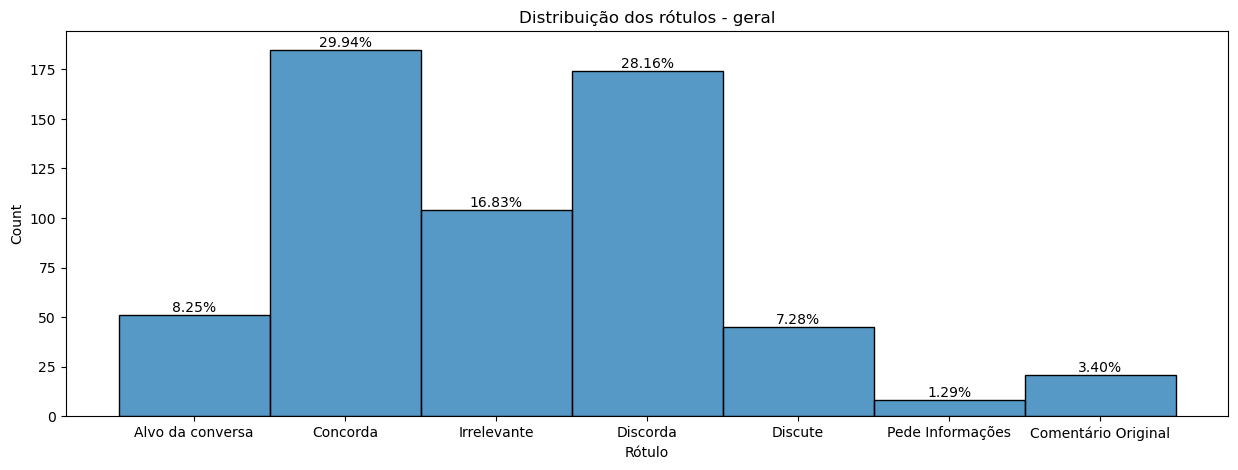

In [86]:
# Distribuição dos rótulos
plt.figure(figsize=(15, 5))
sns.histplot(x='label', data=df)
plt.title('Distribuição dos rótulos - geral')
plt.xlabel('Rótulo')

# colocar label nas "barras" como porcentagem
total = len(df)
for p in plt.gca().patches:
    percentage = f'{p.get_height() / total:.2%}'
    plt.text(p.get_x() + p.get_width() / 2, p.get_height(), percentage, ha='center', va='bottom')

Utilizarei as classes: Concorda, Discorda, Neutro (Discute, Irrelevante ou Pede informações).

In [49]:
# checagem de valores nulos
print(df.isnull().sum())

target_id                  0
target_message             0
id                         0
parent_id                 51
author                     0
parent_name                0
parent_message            32
message                    0
parent_label             116
target_parent_message      0
target_and_message         0
label                     30
dtype: int64


In [63]:
# Linhas onde parent_label é nulo mas parent_message não é
print(df[df['parent_label'].isnull() & df['parent_message'].notnull()].value_counts())

# Linhas onde parent_message é nulo mas parent_label não é
print(df[df['parent_message'].isnull() & df['parent_label'].notnull()].value_counts())

# Contagem cruzada
print(df[['parent_message', 'parent_label']].isnull().value_counts())

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
parent_message  parent_label
False           False           502
                True             84
True            True             32
Name: count, dtype: int64


In [ ]:
# Linhas onde parent_label é nulo mas parent_message não é
sem_parent_label = df[df['parent_label'].isnull() & df['parent_message'].notnull()]
sem_parent_label.count()

target_id                84
target_message           84
id                       84
parent_id                65
author                   84
parent_name              84
parent_message           84
message                  84
parent_label              0
target_parent_message    84
target_and_message       84
label                    65
dtype: int64

In [77]:
# Crie um grafo direcionado
G = nx.DiGraph()

# Adicione nós (comentários)
for idx, row in df.iterrows():
    G.add_node(row['id'])

# Adicione arestas de parent (resposta)
for idx, row in df.iterrows():
    if pd.notnull(row['parent_id']):
        G.add_edge(row['parent_id'], row['id'], relation='parent')

# Adicione arestas de target (alvo)
""" for idx, row in df.iterrows():
    if pd.notnull(row['target_id']):
        G.add_edge(row['target_id'], row['id'], relation='target') """

# Visualização simples (atenção: para muitos nós pode ficar poluído)
""" plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=500, font_size=8, arrows=True)
plt.show() """

' plt.figure(figsize=(12, 8))\npos = nx.spring_layout(G, k=0.5)\nnx.draw(G, pos, with_labels=True, node_size=500, font_size=8, arrows=True)\nplt.show() '

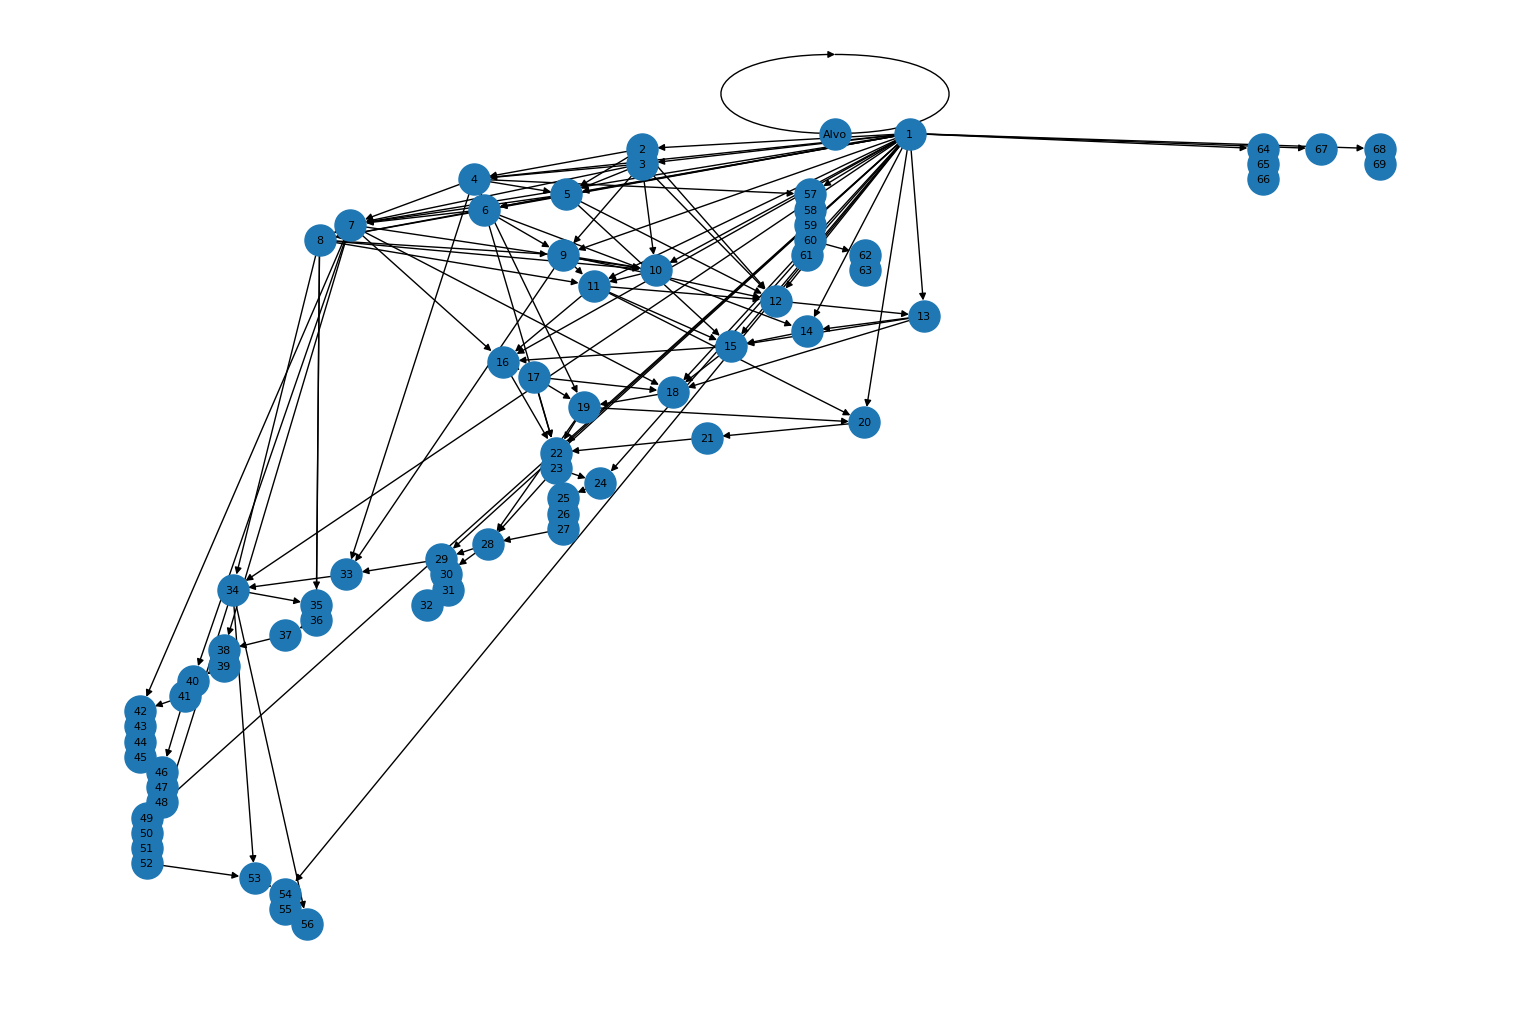

In [80]:
# Visualização hierárquica (top-down)
plt.figure(figsize=(15, 10))
pos = nx.nx_agraph.graphviz_layout(G, prog='dot')  # ou: nx.nx_pydot.graphviz_layout(G, prog='dot')
nx.draw(G, pos, with_labels=True, node_size=500, font_size=8, arrows=True)
plt.show()

Problema: analisando o dataset, temos vários valores de ids repetidos. Isso acontece pois o valor de id é definido no contexto da postagem.

Podemos:
- desconsiderar os ids e utilizar apenas as mensagens já postas na linha de cada comentário (parent_message e target_message), ou
- criar uma coluna de id de postagem, criando um "endereço" para os ids